#### Make Model w/ Larger Dataset

In [1]:
# Lib's Dependencies

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import pandas as pd

In [2]:
insuranceDf = pd.read_csv(r"https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insuranceDf.head(), insuranceDf.dtypes, insuranceDf.shape

(   age     sex     bmi  children smoker     region      charges
 0   19  female  27.900         0    yes  southwest  16884.92400
 1   18    male  33.770         1     no  southeast   1725.55230
 2   28    male  33.000         3     no  southeast   4449.46200
 3   33    male  22.705         0     no  northwest  21984.47061
 4   32    male  28.880         0     no  northwest   3866.85520,
 age           int64
 sex          object
 bmi         float64
 children      int64
 smoker       object
 region       object
 charges     float64
 dtype: object,
 (1338, 7))

In [3]:
# One Hot Encode Pandas
insuranceDf_encoded = pd.get_dummies(insuranceDf)
insuranceDf_encoded.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


##### Data Splitting

In [4]:
# Create Target & Feature

y = insuranceDf_encoded["charges"]
X = insuranceDf_encoded[["age", "bmi", "children", "sex_female", "sex_male", "smoker_no", "smoker_yes",
                         "region_northeast", "region_northwest", "region_southeast", "region_southwest"]]

In [5]:
import sklearn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

##### Model Create & Eval 

Model 1

In [6]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["mae"])

model_1.fit(X_train, y_train, epochs=300, verbose=2)

Epoch 1/300
34/34 - 1s - 39ms/step - loss: 13292.5117 - mae: 13292.5117
Epoch 2/300
34/34 - 0s - 3ms/step - loss: 13159.8281 - mae: 13159.8281
Epoch 3/300
34/34 - 0s - 3ms/step - loss: 12931.2500 - mae: 12931.2500
Epoch 4/300
34/34 - 0s - 3ms/step - loss: 12575.7744 - mae: 12575.7744
Epoch 5/300
34/34 - 0s - 3ms/step - loss: 12083.0781 - mae: 12083.0781
Epoch 6/300
34/34 - 0s - 3ms/step - loss: 11459.4180 - mae: 11459.4180
Epoch 7/300
34/34 - 0s - 3ms/step - loss: 10745.4258 - mae: 10745.4258
Epoch 8/300
34/34 - 0s - 3ms/step - loss: 10018.0596 - mae: 10018.0596
Epoch 9/300
34/34 - 0s - 3ms/step - loss: 9317.0830 - mae: 9317.0830
Epoch 10/300
34/34 - 0s - 6ms/step - loss: 8685.6367 - mae: 8685.6367
Epoch 11/300
34/34 - 0s - 3ms/step - loss: 8180.4214 - mae: 8180.4214
Epoch 12/300
34/34 - 0s - 4ms/step - loss: 7820.0684 - mae: 7820.0684
Epoch 13/300
34/34 - 0s - 3ms/step - loss: 7610.7627 - mae: 7610.7627
Epoch 14/300
34/34 - 0s - 3ms/step - loss: 7514.0391 - mae: 7514.0391
Epoch 15/300

In [7]:
model_1.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3670.4436 - mae: 3670.4436  


[3595.250732421875, 3595.250732421875]

In [8]:
y_train.median(), y_train.mean()

(np.float64(9575.4421), np.float64(13346.089736364485))

Model 2

In [9]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["mae"])

history = model_2.fit(X_train, y_train, epochs=200, verbose=2)

Epoch 1/200
34/34 - 1s - 35ms/step - loss: 13179.9502 - mae: 13179.9502
Epoch 2/200
34/34 - 0s - 3ms/step - loss: 11651.2705 - mae: 11651.2705
Epoch 3/200
34/34 - 0s - 3ms/step - loss: 7994.7881 - mae: 7994.7881
Epoch 4/200
34/34 - 0s - 3ms/step - loss: 7382.6348 - mae: 7382.6348
Epoch 5/200
34/34 - 0s - 3ms/step - loss: 7307.1582 - mae: 7307.1582
Epoch 6/200
34/34 - 0s - 3ms/step - loss: 7230.5811 - mae: 7230.5811
Epoch 7/200
34/34 - 0s - 2ms/step - loss: 7147.1528 - mae: 7147.1528
Epoch 8/200
34/34 - 0s - 3ms/step - loss: 7057.0811 - mae: 7057.0811
Epoch 9/200
34/34 - 0s - 3ms/step - loss: 6959.9409 - mae: 6959.9409
Epoch 10/200
34/34 - 0s - 3ms/step - loss: 6844.4404 - mae: 6844.4404
Epoch 11/200
34/34 - 0s - 3ms/step - loss: 6722.5181 - mae: 6722.5181
Epoch 12/200
34/34 - 0s - 3ms/step - loss: 6598.6216 - mae: 6598.6216
Epoch 13/200
34/34 - 0s - 3ms/step - loss: 6507.3115 - mae: 6507.3115
Epoch 14/200
34/34 - 0s - 3ms/step - loss: 6451.5332 - mae: 6451.5332
Epoch 15/200
34/34 - 0s 

In [10]:
model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3261.3030 - mae: 3261.3030


[3210.699462890625, 3210.699462890625]

In [11]:
model_1.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3670.4436 - mae: 3670.4436 


[3595.250732421875, 3595.250732421875]

Text(0.5, 0, 'epochs')

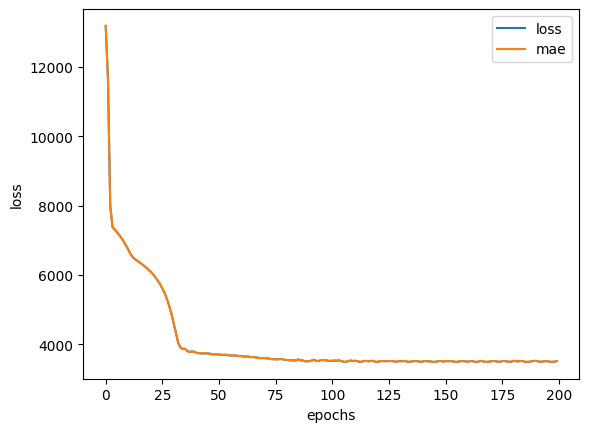

In [12]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

##### Preprocessing Data (Normalization & Standarization)

Steps in Modelling w/ Tensorflow
1. Turn all data into numbers (Neural network can't handle string)
2. Make sure all of your tensors are in the right shape
3. Scale features (Noramalize or standarize, neural network tend to prefer normalization)

In [13]:
# X.columns

In [14]:
# X["age"].plot(kind="hist")

In [15]:
# X["bmi"].plot(kind="hist")

In [16]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

insuranceDf2 = pd.read_csv(r"https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insuranceDf2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
# Create column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]), #Turn all values in theese columns between 1 & 0
    (OneHotEncoder(handle_unknown="ignore"),["sex", "smoker", "region"])
)

# Create X & y
X = insuranceDf2.drop("charges" ,axis=1)
y = insuranceDf2["charges"]

# Train Test Splitting
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit
ct.fit(X_train2)

# Transform training and test w/ normalization (MMX) and OneHotEncoder
X_train2_normal = ct.transform(X_train2)
X_test2_normal = ct.transform(X_test2) 


In [18]:
# New look
X_train2.loc[0]

age                19
sex            female
bmi              27.9
children            0
smoker            yes
region      southwest
Name: 0, dtype: object

In [19]:
X_train2_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [20]:
X_train2.shape, X_train2_normal.shape

((1070, 6), (1070, 11))

In [21]:
# Build a neural network
model_A = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1)
])

model_A.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["mae"])

history2 = model_A.fit(X_train2_normal, y_train2, epochs=200, verbose=2)

Epoch 1/200
34/34 - 2s - 57ms/step - loss: 13339.0586 - mae: 13339.0586
Epoch 2/200
34/34 - 0s - 4ms/step - loss: 13247.6816 - mae: 13247.6816
Epoch 3/200
34/34 - 0s - 4ms/step - loss: 12800.2061 - mae: 12800.2061
Epoch 4/200
34/34 - 0s - 9ms/step - loss: 11564.6045 - mae: 11564.6045
Epoch 5/200
34/34 - 0s - 5ms/step - loss: 9720.0811 - mae: 9720.0811
Epoch 6/200
34/34 - 0s - 5ms/step - loss: 8322.1416 - mae: 8322.1416
Epoch 7/200
34/34 - 0s - 4ms/step - loss: 7867.0073 - mae: 7867.0073
Epoch 8/200
34/34 - 0s - 5ms/step - loss: 7702.7305 - mae: 7702.7305
Epoch 9/200
34/34 - 0s - 3ms/step - loss: 7545.2100 - mae: 7545.2100
Epoch 10/200
34/34 - 0s - 4ms/step - loss: 7379.1646 - mae: 7379.1646
Epoch 11/200
34/34 - 0s - 4ms/step - loss: 7198.3730 - mae: 7198.3730
Epoch 12/200
34/34 - 0s - 4ms/step - loss: 6998.4312 - mae: 6998.4312
Epoch 13/200
34/34 - 0s - 3ms/step - loss: 6772.7676 - mae: 6772.7676
Epoch 14/200
34/34 - 0s - 4ms/step - loss: 6511.4287 - mae: 6511.4287
Epoch 15/200
34/34 -

In [22]:
model_A.evaluate(X_test2_normal, y_test2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3212.6589 - mae: 3212.6589  


[3159.470458984375, 3159.470458984375]

Text(0.5, 0, 'epochs')

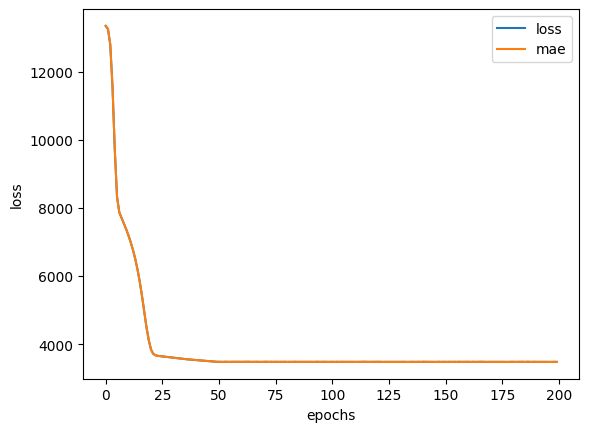

In [23]:
pd.DataFrame(history2.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")